# Surrogate accuracy comparison (Appendix)

Out-of-optimisation accuracy comparison of the flexibility purchase-cost
surrogates against the **true analytical cost** (Eq. 10c), for the revised
manuscript appendix.

**Methods compared**
- **PWL** (2-D, bilinear) with 3 / 5 / 10 / 20 breakpoints — the shaping
  parameters `(a, b)` are *fixed per sample* (evaluated exactly), so the PWL
  interpolates only over `(x, y) = (flexibility, max flexibility)`. This makes
  PWL a **2-D** surrogate that is supplied the exact `(a, b)` for every point —
  i.e. it is *better-informed* than the 4-D neural networks, not handicapped.
- **UCNN** — unconstrained ReLU network (`Unconstrained model/Base_NN.keras`).
- **ICNN** — input-convex ReLU network (`FICNN model/Base_FICNN.keras`).

**Data:** 10,000 random samples over the training domain
`x in [0.098, 0.98*y], y in [0.1, 20], a in [4,8], b in [0.25,2]`.

> **SIGN CONVENTION:** all quantities (true value, PWL, UCNN, ICNN) are expressed
> as **positive** cost in DKK. This is consistent with the stored PWL breakpoints
> (`prosumRespMultiPWL.pickle`, positive) and the NN output scaling `Z in [0, 741.868]`.
> The consistency-check cell at the end confirms the PWL construction reproduces the
> stored breakpoints exactly.

In [1]:
from tensorflow.keras.models import load_model
import pandas as pd
import os
import glob
import matplotlib
from matplotlib import pyplot as plt
import numpy as np
import random
import math
import pickle
import time
import sys 

current_path = os.getcwd()
cwd = os.path.dirname(current_path)
sys.path.append(os.path.join(cwd, "utilities"))

from pickle_file_operations import read_pickle, write_pickle

In [2]:
pickle_path = os.path.join(cwd, "pickle files")
optimization_input_path = os.path.join(cwd, "optimization input")

## Configuration

In [3]:
# ----- global config -----
NUM_VALS = 100000        # random test points (per request)
RANDOM_SEED = 1688
nPieces = [3, 5, 10, 20]  # PWL breakpoint counts for the appendix sweep

maxFlexVal = 20
minFlexVal = 0.1

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# SIGN CONVENTION: all quantities (True Value, PWL, UCNN, ICNN) are POSITIVE cost
# in DKK. This matches (i) the stored prosumRespMultiPWL.pickle breakpoints, which
# are positive, and (ii) the NN output scaling Z in [0, 741.868]. See the
# consistency-check cell at the end (cost breakpoints should match).

## True cost and PWL machinery (from the original accuracy script)

In [4]:
def _lambdaCost(x, y, a, b):
    # Raw analytical cost kernel (Eq. 10c form), ORIGINAL sign (no extra -1).
    # With b passed as +b this returns the NEGATED cost; with b passed as -b it
    # returns POSITIVE cost. The stored PWL breakpoints use lambdaCost(a, -b) and
    # are POSITIVE, so we mirror that convention throughout (see cells below).
    return round(b ** -1 * x * (math.log((y / x) - 1) - a), 3)

def lambdaCost(Flexibility, maxFlexibility, a, b, nPiece):
    lambdaCostPoints = []
    for x in Flexibility:
        for y in maxFlexibility:
            if x < y:
                lambdaCostPoints.append(_lambdaCost(x, y, a, b))
            else:
                lambdaCostPoints.append(0)
    lambdaCostPoints = np.reshape(lambdaCostPoints, (nPiece, nPiece))
    return lambdaCostPoints

def breakpointCalculator(minVal, maxVal, steps):
    profile, stepSize = np.linspace(stop=maxVal, start=minVal, num=steps, retstep=2)
    return [round(x, 3) for x in profile], round(stepSize, 3)

In [5]:
def PWL_solution(x_star, y_star, PWL_points, nPiece):
    """Bilinear (triangular) interpolation of the PWL surface at (x_star, y_star)."""
    x = PWL_points['x']
    y = PWL_points['y']
    z = PWL_points['z']
    delta_x = PWL_points['delta x']
    delta_y = PWL_points['delta y']

    # Identify the enclosing box
    if math.floor((x_star - x[0]) / delta_x) == nPiece - 1:
        x_indices = [nPiece - 2, nPiece - 1]
    else:
        x_indices = [math.floor((x_star - x[0]) / delta_x), math.floor((x_star - x[0]) / delta_x) + 1]

    if math.floor((y_star - y[0]) / delta_y) == nPiece - 1:
        y_indices = [nPiece - 2, nPiece - 1]
    else:
        y_indices = [math.floor((y_star - y[0]) / delta_y), math.floor((y_star - y[0]) / delta_y) + 1]

    # Pick the triangle within the box
    if math.atan2(y_star - y[0], x_star - x[0]) <= math.pi / 4:
        x_vals = [x[x_indices[0]], x[x_indices[1]], x[x_indices[1]]]
        y_vals = [y[y_indices[0]], y[y_indices[0]], y[y_indices[1]]]
        z_vals = np.array([z[x_indices[0]][y_indices[0]], z[x_indices[1]][y_indices[0]], z[x_indices[1]][y_indices[1]]])
    else:
        x_vals = [x[x_indices[0]], x[x_indices[0]], x[x_indices[1]]]
        y_vals = [y[y_indices[0]], y[y_indices[1]], y[y_indices[1]]]
        z_vals = np.array([z[x_indices[0]][y_indices[0]], z[x_indices[0]][y_indices[1]], z[x_indices[1]][y_indices[1]]])

    A = np.array([x_vals, y_vals, [1, 1, 1]])
    b = np.array([[x_star], [y_star], [1]])
    omega = np.linalg.inv(A) @ b
    z_star = np.transpose(omega) @ np.transpose(z_vals)
    return float(np.asarray(z_star).reshape(-1)[0])

## Load the neural networks (revised paths)

In [6]:
current_directory = os.getcwd()
parent_directory = os.path.dirname(current_directory)
nn_path = os.path.join(parent_directory, "NN models")

# Revised model paths:
#   UCNN -> Unconstrained model/Base_NN.keras
#   ICNN -> FICNN model/Base_FICNN.keras
ucnn_model = load_model(os.path.join(nn_path, "Unconstrained model", "Base_NN.keras"))
icnn_model = load_model(os.path.join(nn_path, "FICNN model", "Base_FICNN.keras"))

print("UCNN inputs:", ucnn_model.input_shape, " ICNN inputs:", icnn_model.input_shape)

UCNN inputs: (None, 4)  ICNN inputs: (None, 4)


In [7]:
# Min-max scaling values (identical to the original accuracy script)
min_max_vals = {'A': {'min': 4,          'max': 8},
                'B': {'min': 0.25,       'max': 2},
                'X': {'min': 0.1 * 0.98, 'max': 20 * 0.98},
                'Y': {'min': 0.1,        'max': 20},
                'Z': {'min': 0,          'max': 741.868}}

def min_max_scale(min_X, max_X, X):
    return [(x - min_X) / (max_X - min_X) for x in X]

def inv_min_max_scale(min_X, max_X, scaled_X):
    return [x * (max_X - min_X) + min_X for x in scaled_X]

## Generate 10,000 random test points

In [8]:
input_dict = {'X': [], 'Y': [], 'A': [], 'B': []}
for _ in range(NUM_VALS):
    y = round(random.uniform(0.1, 20), 3)
    x = round(random.uniform(0.1 * 0.98, 0.98 * y), 3)   # enforces x <= 0.98*y
    a = round(random.uniform(4, 8), 3)
    b = round(random.uniform(0.25, 2), 3)
    input_dict['X'].append(x)
    input_dict['Y'].append(y)
    input_dict['A'].append(a)
    input_dict['B'].append(b)

input_DF = pd.DataFrame(input_dict)
print(input_DF.describe())

                   X              Y              A              B
count  100000.000000  100000.000000  100000.000000  100000.000000
mean        4.953175      10.028357       6.000985       1.126007
std         4.289860       5.732910       1.154787       0.505888
min         0.098000       0.100000       4.000000       0.250000
25%         1.399000       5.084750       4.998000       0.687000
50%         3.713000      10.026000       6.001000       1.128000
75%         7.528000      14.974000       7.001000       1.566000
max        19.541000      19.999000       8.000000       2.000000


## PWL predictions (2-D, per-sample fixed shaping parameters)

For each test point the PWL breakpoints are rebuilt using that point's exact
`(a, b)`, then bilinearly interpolated over `(x, y)`. This is the fixed-parameter
2-D PWL referred to in the appendix text.

In [9]:
%%time
output_dict = {'True Value': []}
for nPiece in nPieces:
    output_dict[f"{nPiece} piece PWL"] = []

for row in input_DF.index:
    a = input_DF['A'].iloc[row]
    b = input_DF['B'].iloc[row]
    # POSITIVE true cost: _lambdaCost(a, -b) yields positive (matches stored breakpoints).
    TV = _lambdaCost(input_DF['X'].iloc[row], input_DF['Y'].iloc[row], a, -b)
    output_dict['True Value'].append(TV)

    for nPiece in nPieces:
        maxFlexibilityPoints, maxFlexStepsize = breakpointCalculator(minFlexVal, maxFlexVal, nPiece)
        flexibilityPoints, flexStepsize = breakpointCalculator(minFlexVal * 0.98, maxFlexVal * 0.98, nPiece)
        # POSITIVE PWL breakpoints, identical to the deployed prosumRespMultiPWL.pickle build.
        lambdaCostPoints = lambdaCost(flexibilityPoints, maxFlexibilityPoints, a, -b, nPiece)
        PWL_params = {'x': flexibilityPoints, 'z': lambdaCostPoints, 'y': maxFlexibilityPoints,
                      'delta x': flexStepsize, 'delta y': maxFlexStepsize}
        z_hat = PWL_solution(input_DF['X'].iloc[row], input_DF['Y'].iloc[row], PWL_params, nPiece)
        output_dict[f"{nPiece} piece PWL"].append(z_hat)   # already positive

CPU times: total: 6min 29s
Wall time: 6min 30s


## Neural network predictions

Inputs are scaled with the same min-max ranges as training; outputs are inverse
scaled back to DKK. `COST_SIGN` is applied so NN outputs share the sign
convention of `True Value`.

In [10]:
%%time
normDF = pd.DataFrame()
for column in input_DF.columns:
    normDF[column] = min_max_scale(min_max_vals[column]['min'],
                                   min_max_vals[column]['max'],
                                   input_DF[column].to_list())

ucnn_pred = inv_min_max_scale(min_max_vals['Z']['min'], min_max_vals['Z']['max'],
                              ucnn_model.predict(normDF, verbose=0))
icnn_pred = inv_min_max_scale(min_max_vals['Z']['min'], min_max_vals['Z']['max'],
                              icnn_model.predict(normDF, verbose=0))

# NNs were trained with output scaled to Z in [0, 741.868] -> POSITIVE cost.
# True Value and PWL are also positive, so all three are directly comparable.
output_dict['UCNN'] = np.reshape(ucnn_pred, (NUM_VALS,))
output_dict['ICNN'] = np.reshape(icnn_pred, (NUM_VALS,))

for key in list(output_dict.keys()):
    output_dict[key] = np.reshape(np.array(output_dict[key], dtype=float), (NUM_VALS,))

CPU times: total: 12.5 s
Wall time: 10.7 s


## Assemble predictions and errors

In [11]:
pred_DF = pd.DataFrame(output_dict)
method_cols = [c for c in pred_DF.columns if c != 'True Value']
print("methods:", method_cols)
pred_DF.head()

methods: ['3 piece PWL', '5 piece PWL', '10 piece PWL', '20 piece PWL', 'UCNN', 'ICNN']


,True Value,3 piece PWL,5 piece PWL,10 piece PWL,20 piece PWL,UCNN,ICNN
0,36.043,35.841405,36.871455,36.007404,36.074902,33.350716,33.021343
1,1.363,3.115104,2.824184,1.795054,1.597205,0.722596,4.961789
2,5.010,8.341363,8.274490,5.117966,5.146467,5.250167,4.861633
3,87.936,109.993876,85.587059,87.126439,88.120128,86.678558,97.048897
4,63.503,96.004048,61.194153,64.795886,63.880277,64.068451,63.229935


In [12]:
# Absolute error and percentage error.
# Percentage error is guarded: points whose TRUE cost is near zero produce
# meaningless huge percentages, so they are masked out of the % metrics only
# (they remain in the absolute-error / RMSE metrics).
TRUE_FLOOR = 1.0  # DKK; below this the % error is treated as undefined

abs_err = {}
pct_err = {}
tv = pred_DF['True Value']
small_mask = tv.abs() < TRUE_FLOOR
for col in method_cols:
    diff = pred_DF[col] - tv
    abs_err[col] = diff.abs()
    with np.errstate(divide='ignore', invalid='ignore'):
        pe = 100.0 * diff / tv
    pe = pe.replace([np.inf, -np.inf], np.nan)
    pe[small_mask] = np.nan          # mask near-zero-true-cost points
    pct_err[col] = pe

abs_err_DF = pd.DataFrame(abs_err)
pct_err_DF = pd.DataFrame(pct_err)

print(f"points excluded from % metrics (|true| < {TRUE_FLOOR} DKK): {int(small_mask.sum())} / {len(tv)}")

points excluded from % metrics (|true| < 1.0 DKK): 5524 / 100000


## Accuracy metrics table

In [13]:
def rmse(series):
    return float(np.sqrt(np.mean(np.square(series))))

metrics = pd.DataFrame(index=method_cols)
metrics["RMSE (DKK)"]      = [rmse(pred_DF[c] - pred_DF['True Value']) for c in method_cols]
metrics["MAE (DKK)"]       = [abs_err_DF[c].mean() for c in method_cols]
metrics["Median AE (DKK)"] = [abs_err_DF[c].median() for c in method_cols]
metrics["Max AE (DKK)"]    = [abs_err_DF[c].max() for c in method_cols]
metrics["MAPE (%)"]        = [pct_err_DF[c].abs().mean() for c in method_cols]
metrics["Median APE (%)"]  = [pct_err_DF[c].abs().median() for c in method_cols]
# fraction of points with |pct error| > pct%
pct = 5
metrics[">" + str(pct) + "% error (%)"]   = [100.0 * (pct_err_DF[c].abs() > pct).mean() for c in method_cols]
# R^2 (coefficient of determination)
def r2(col):
    ss_res = float(np.sum(np.square(pred_DF[col] - pred_DF['True Value'])))
    ss_tot = float(np.sum(np.square(pred_DF['True Value'] - pred_DF['True Value'].mean())))
    return 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
metrics["R2"] = [r2(c) for c in method_cols]

metrics_display = metrics.copy()
metrics_display = metrics_display.round(3)
metrics_display

,RMSE (DKK),MAE (DKK),Median AE (DKK),Max AE (DKK),MAPE (%),Median APE (%),>5% error (%),R2
3 piece PWL,13.885,8.821,5.113,123.336,42.806,28.487,85.791,0.940
5 piece PWL,7.137,3.966,1.663,87.323,22.950,11.890,62.906,0.984
10 piece PWL,3.110,1.417,0.412,71.577,9.799,1.847,34.904,0.997
20 piece PWL,1.369,0.507,0.105,39.750,3.883,0.444,16.360,0.999
UCNN,1.648,1.059,0.724,37.297,8.081,3.196,34.143,0.999
ICNN,6.517,4.054,2.236,66.617,32.744,9.800,69.007,0.987


In [14]:
# LaTeX for the appendix accuracy table
print(metrics.round(3).to_latex())

\begin{tabular}{lrrrrrrrr}
\toprule
 & RMSE (DKK) & MAE (DKK) & Median AE (DKK) & Max AE (DKK) & MAPE (%) & Median APE (%) & >5% error (%) & R2 \\
\midrule
3 piece PWL & 13.885000 & 8.821000 & 5.113000 & 123.336000 & 42.806000 & 28.487000 & 85.791000 & 0.940000 \\
5 piece PWL & 7.137000 & 3.966000 & 1.663000 & 87.323000 & 22.950000 & 11.890000 & 62.906000 & 0.984000 \\
10 piece PWL & 3.110000 & 1.417000 & 0.412000 & 71.577000 & 9.799000 & 1.847000 & 34.904000 & 0.997000 \\
20 piece PWL & 1.369000 & 0.507000 & 0.105000 & 39.750000 & 3.883000 & 0.444000 & 16.360000 & 0.999000 \\
UCNN & 1.648000 & 1.059000 & 0.724000 & 37.297000 & 8.081000 & 3.196000 & 34.143000 & 0.999000 \\
ICNN & 6.517000 & 4.054000 & 2.236000 & 66.617000 & 32.744000 & 9.800000 & 69.007000 & 0.987000 \\
\bottomrule
\end{tabular}



## Figures

### (a) Percentage-error distribution (headline figure)

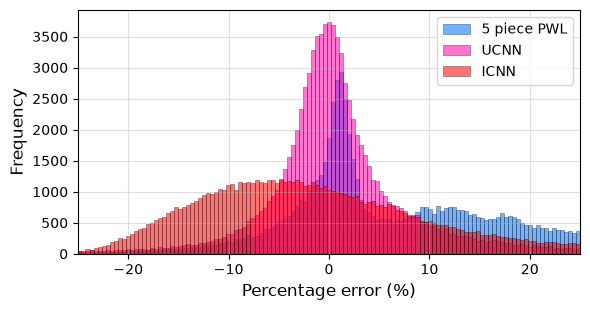

In [31]:
# Overlaid histograms of percentage error for the key methods.
makedir_target = os.path.join(parent_directory, "images_revised")
if not os.path.exists(makedir_target):
    os.mkdir(makedir_target)

focus = [c for c in ["5 piece PWL", "UCNN", "ICNN"] if c in method_cols]
cmap = matplotlib.colormaps['hsv']
color_map = {"5 piece PWL": cmap(0.60), "UCNN": cmap(0.90), "ICNN": cmap(0.0)}
bins = np.linspace(-100, 100, 500)

fig, ax = plt.subplots(figsize=(6, 3.2))
for col in focus:
    ax.hist(pct_err_DF[col].dropna(), bins=bins, alpha=0.55, label=col,
            color=color_map.get(col, None), edgecolor="black", linewidth=0.4)
ax.set_xlabel("Percentage error (%)", fontsize="large")
ax.set_ylabel("Frequency", fontsize="large")
ax.set_xlim(-25, 25)
ax.legend(fontsize="medium")
ax.grid(alpha=0.4, zorder=0)
plt.tight_layout()
plt.savefig(os.path.join(makedir_target, "appendix_accuracy_pct_error_hist.pdf"), bbox_inches="tight")
plt.show()

In [ ]:
method_colors = {
    "PWL": "xkcd:green",
    "Gurobi ML": "xkcd:purple",
    "PCTAR": "xkcd:orange",
    "PCAR": "xkcd:blue",
    "ICNN": "xkcd:red",
}


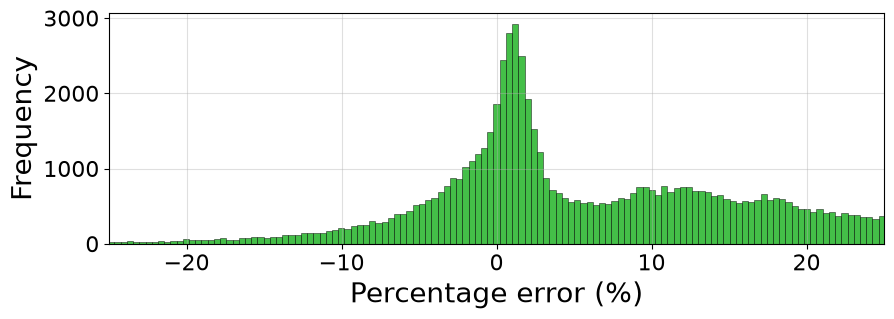

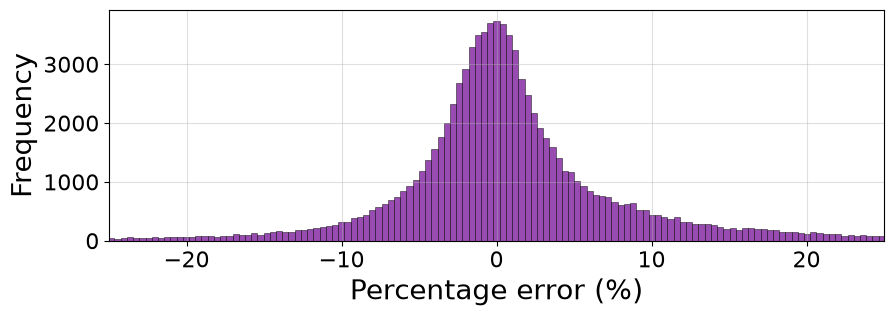

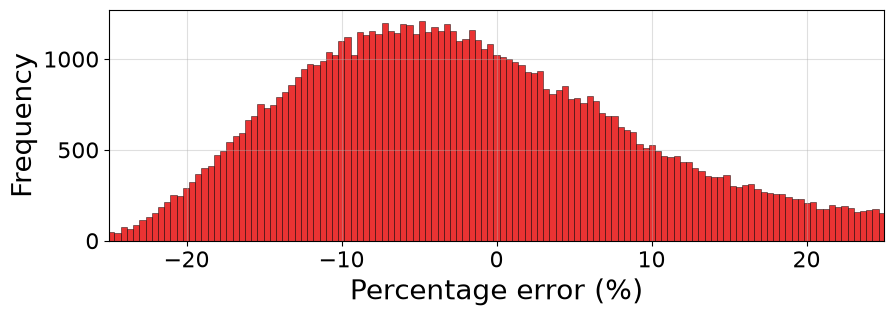

In [62]:
# Separate histograms of percentage error for the key methods (one file each).
makedir_target = os.path.join(parent_directory, "images_revised")
if not os.path.exists(makedir_target):
    os.mkdir(makedir_target)

focus = [c for c in ["5 piece PWL", "UCNN", "ICNN"] if c in method_cols]
cmap = matplotlib.colormaps['hsv']
color_map = {"5 piece PWL": "xkcd:green", "UCNN": "xkcd:purple", "ICNN": "xkcd:red"}
bins = np.linspace(-100, 100, 500)

# Filename-safe slug for each method (e.g. "5 piece PWL" -> "5_piece_PWL").
def _slug(name):
    return name.replace(" ", "_")

for col in focus:
    fig, ax = plt.subplots(figsize=(10, 3))
    ax.hist(pct_err_DF[col].dropna(), bins=bins, label=col,
            color=color_map.get(col, None), alpha=0.8, edgecolor="black", linewidth=0.4)
    ax.set_xlabel("Percentage error (%)", fontsize=20)
    ax.set_ylabel("Frequency", fontsize=20)
    ax.tick_params(axis='both', labelsize=16)
    ax.set_xlim(-25, 25)
    # ax.legend(fontsize="medium")
    ax.grid(alpha=0.4, zorder=0)
    plt.savefig(
        os.path.join(makedir_target, f"appendix_accuracy_pct_error_hist_{_slug(col)}.pdf"),
        bbox_inches="tight",
    )
    plt.show()
    plt.close(fig)

### (b) RMSE bar chart across all methods (incl. PWL sweep)

C:\Users\a1842184\AppData\Local\Temp\ipykernel_2636\3505987788.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(order, rotation=30, ha="right", fontsize="medium")


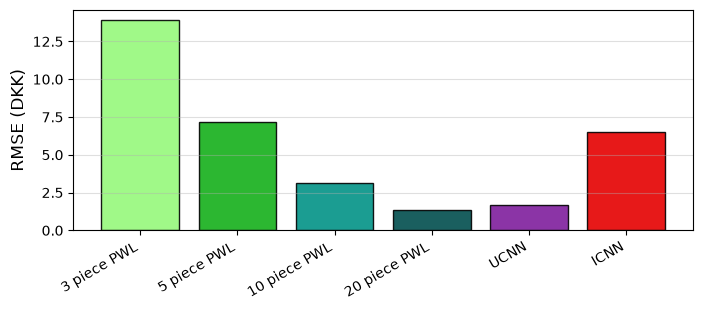

In [16]:
fig, ax = plt.subplots(figsize=(7, 3.2))
order = [c for c in ["3 piece PWL", "5 piece PWL", "10 piece PWL", "20 piece PWL", "UCNN", "ICNN"] if c in method_cols]
vals = [metrics.loc[m, "RMSE (DKK)"] for m in order]
barcolors = ["xkcd:light green", "xkcd:green", "xkcd:teal", "xkcd:dark teal", "xkcd:purple", "xkcd:red"][:len(order)]
ax.bar(order, vals, color=barcolors, edgecolor="black", alpha=0.9)
ax.set_ylabel("RMSE (DKK)", fontsize="large")
ax.set_xticklabels(order, rotation=30, ha="right", fontsize="medium")
ax.grid(axis="y", alpha=0.4, zorder=0)
plt.tight_layout()
plt.savefig(os.path.join(makedir_target, "appendix_accuracy_rmse_bar.pdf"), bbox_inches="tight")
plt.show()

### (c) Predicted vs true scatter (UCNN, ICNN, 5-piece PWL)

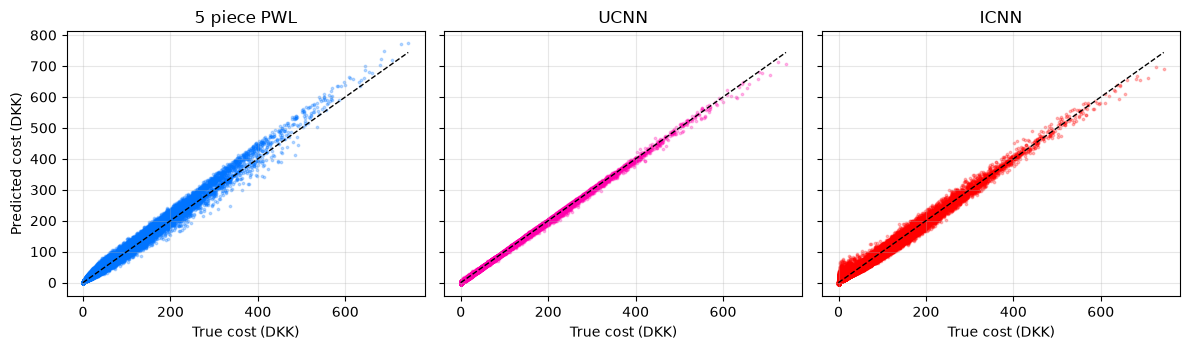

In [17]:
focus_scatter = [c for c in ["5 piece PWL", "UCNN", "ICNN"] if c in method_cols]
fig, axes = plt.subplots(1, len(focus_scatter), figsize=(4 * len(focus_scatter), 3.6), sharex=True, sharey=True)
if len(focus_scatter) == 1:
    axes = [axes]
lims = [pred_DF['True Value'].min(), pred_DF['True Value'].max()]
for axc, col in zip(axes, focus_scatter):
    axc.scatter(pred_DF['True Value'], pred_DF[col], s=3, alpha=0.25,
                color=color_map.get(col, "xkcd:grey"))
    axc.plot(lims, lims, "k--", linewidth=1)
    axc.set_title(col, fontsize="large")
    axc.set_xlabel("True cost (DKK)", fontsize="medium")
    axc.grid(alpha=0.3)
axes[0].set_ylabel("Predicted cost (DKK)", fontsize="medium")
plt.tight_layout()
plt.savefig(os.path.join(makedir_target, "appendix_accuracy_scatter.pdf"), bbox_inches="tight")
plt.show()

In [42]:
pred_DF.to_csv("Predicted_and_true_vals.csv")

### (d) Error vs flexibility ratio (where does each surrogate struggle?)

C:\Users\a1842184\AppData\Local\Temp\ipykernel_2636\2105720473.py:12: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\a1842184\AppData\Local\Temp\ipykernel_2636\2105720473.py:13: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(os.path.join(makedir_target, "appendix_accuracy_error_vs_ratio.pdf"), bbox_inches="tight")
C:\Users\a1842184\Anaconda3\envs\nlp_scip\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


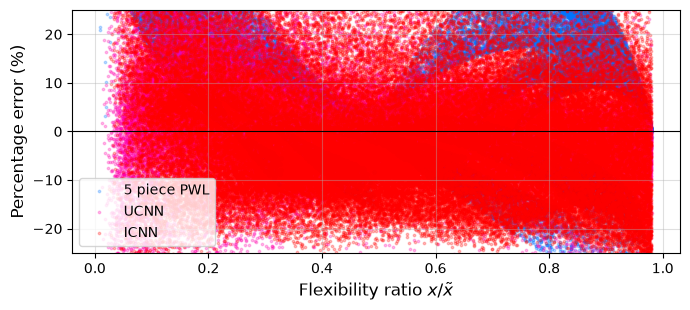

In [18]:
# Percentage error vs (x / y) ratio, which controls proximity to the singularity.
ratio = (input_DF['X'] / input_DF['Y']).values
fig, ax = plt.subplots(figsize=(7, 3.2))
for col in [c for c in ["5 piece PWL", "UCNN", "ICNN"] if c in method_cols]:
    ax.scatter(ratio, pct_err_DF[col], s=3, alpha=0.25, label=col, color=color_map.get(col, None))
ax.axhline(0, color="k", linewidth=0.8)
ax.set_xlabel(r"Flexibility ratio $x/\tilde{x}$", fontsize="large")
ax.set_ylabel("Percentage error (%)", fontsize="large")
ax.set_ylim(-25, 25)
ax.legend(fontsize="medium")
ax.grid(alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(makedir_target, "appendix_accuracy_error_vs_ratio.pdf"), bbox_inches="tight")
plt.show()

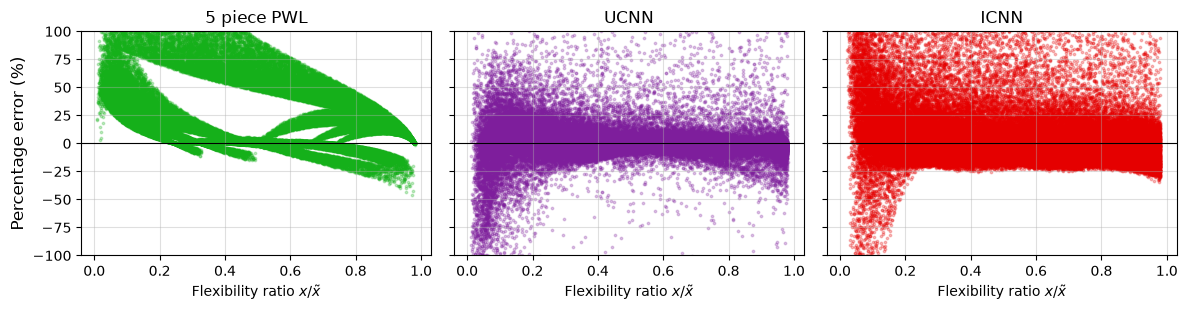

In [56]:
# Percentage error vs (x / y) ratio, which controls proximity to the singularity.
ratio = (input_DF['X'] / input_DF['Y']).values
cols = [c for c in ["5 piece PWL", "UCNN", "ICNN"] if c in method_cols]

fig, axes = plt.subplots(1, len(cols), figsize=(4 * len(cols), 3.2),
                         sharex=True, sharey=True)
if len(cols) == 1:
    axes = [axes]

for ax, col in zip(axes, cols):
    ax.scatter(ratio, pct_err_DF[col], s=3, alpha=0.25, color=color_map.get(col, None))
    ax.axhline(0, color="k", linewidth=0.8)
    ax.set_title(col, fontsize="large")
    ax.set_xlabel(r"Flexibility ratio $x/\tilde{x}$", fontsize="medium")
    ax.grid(alpha=0.4)

axes[0].set_ylabel("Percentage error (%)", fontsize="large")
axes[0].set_ylim(-100, 100)

plt.tight_layout()
plt.savefig(os.path.join(makedir_target, "appendix_accuracy_error_vs_ratio.pdf"), bbox_inches="tight")
plt.show()

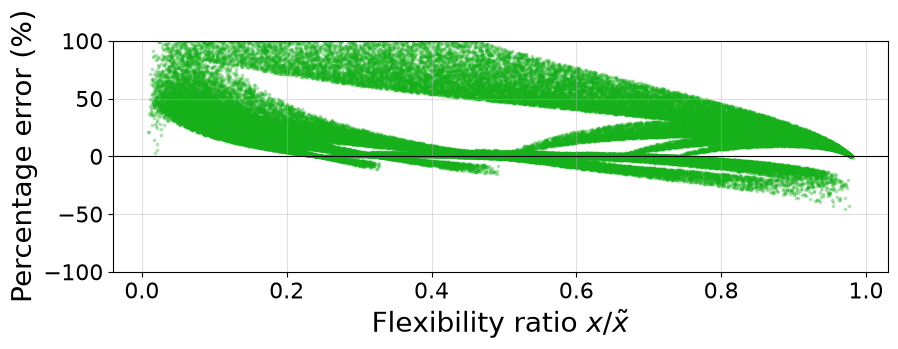

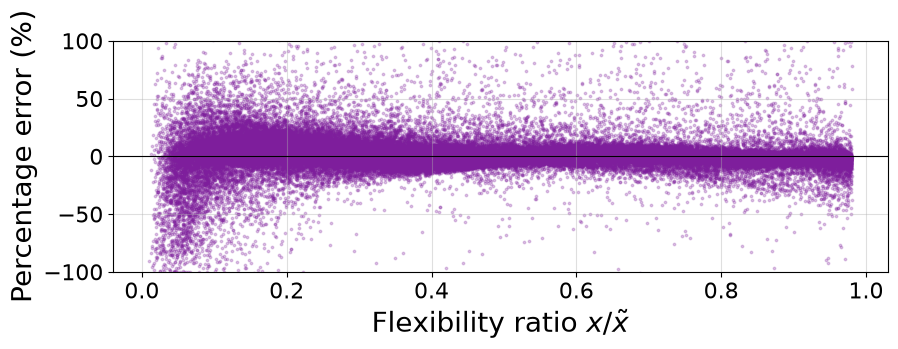

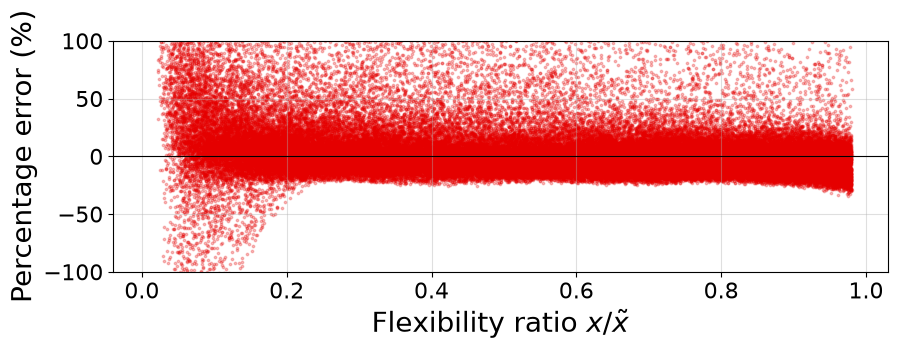

In [66]:
# Percentage error vs (x / y) ratio, one file per method.
ratio = (input_DF['X'] / input_DF['Y']).values
cols = [c for c in ["5 piece PWL", "UCNN", "ICNN"] if c in method_cols]

# Filename-safe slug (e.g. "5 piece PWL" -> "5_piece_PWL").
def _slug(name):
    return name.replace(" ", "_")

for col in cols:
    fig, ax = plt.subplots(figsize=(10, 3))
    step = 1  # plot ~20k points instead of 100k
    r = ratio[::step]
    e = pct_err_DF[col].values[::step]
    ax.scatter(r, e, s=3, alpha=0.25, color=color_map.get(col, None), rasterized=True)
    # ax.scatter(ratio, pct_err_DF[col], s=3, alpha=0.25, color=color_map.get(col, None))
    ax.axhline(0, color="k", linewidth=0.8)
    ax.set_xlabel(r"Flexibility ratio $x/\tilde{x}$", fontsize=20)
    ax.set_ylabel("Percentage error (%)", fontsize=20)
    ax.tick_params(axis='both', labelsize=16)
    ax.set_ylim(-100, 100)
    ax.grid(alpha=0.4)
    plt.savefig(
        os.path.join(makedir_target, f"appendix_accuracy_error_vs_ratio_{_slug(col)}.pdf"),
        bbox_inches="tight",
    )
    plt.savefig(os.path.join(makedir_target,
            f"appendix_accuracy_error_vs_ratio_{_slug(col)}.png"),
            bbox_inches="tight", dpi=250)
    plt.show()
    plt.close(fig)

In [40]:
pct_err_DF["Ratio"] = ratio
pct_err_DF.to_csv("ratio_error.csv")

## Notes for the appendix write-up

- **PWL is 2-D and better-informed:** for every test point the PWL breakpoints are
  rebuilt with that point's exact `(a, b)`, so PWL interpolates only over `(x, y)`
  while receiving the true shaping parameters. The 4-D UCNN/ICNN must instead learn
  the `(a, b)` dependence from data. Any PWL RMSE advantage therefore reflects this
  information asymmetry, not an intrinsic superiority of the embedding — this is the
  point to make when contrasting with the in-optimisation results.
- **Sign convention (resolved):** all quantities are positive cost (DKK). The PWL
  breakpoints are built with `lambdaCost(a, -b)` to match the deployed
  `prosumRespMultiPWL.pickle` (verified by the consistency-check cell). If errors
  are unexpectedly ~200%, re-check that the stored breakpoints are still positive.
- **Metrics table** gives RMSE / MAE / median AE / max AE / MAPE / >5% fraction / R²
  per method. RMSE (DKK) is the headline; the >5% fraction mirrors the original
  script's accuracy criterion.
- **Figures saved to `images_revised/`:** percentage-error histogram, RMSE bar,
  predicted-vs-true scatter, and error-vs-ratio diagnostic.
- 10,000 points is a placeholder ("for now"); bump `NUM_VALS` for the final run.


In [20]:
# --- Consistency check: does our PWL construction match the stored breakpoints? ---
# Stored tuple is (a, -b) with the sign already applied. Our cell-14 build calls
# lambdaCost(a, -b) with a POSITIVE sampled b, i.e. it passes the SAME value as the
# stored second element. So rebuilding with the stored (a, -b) must reproduce the
# stored POSITIVE cost breakpoints exactly.
import numpy as np

stored = read_pickle(os.path.join(pickle_path, "prosumRespMultiPWL.pickle"))
nPiece_chk = 5
hour_chk = 0
a_chk, negb_chk = stored[nPiece_chk][hour_chk]['(a, b)']   # (a, -b), sign already applied

maxF, _ = breakpointCalculator(minFlexVal, maxFlexVal, nPiece_chk)
flexF, _ = breakpointCalculator(minFlexVal * 0.98, maxFlexVal * 0.98, nPiece_chk)
z_rebuilt = lambdaCost(flexF, maxF, a_chk, negb_chk, nPiece_chk)

print("flex breakpoints match:",
      np.allclose(flexF, stored[nPiece_chk][hour_chk]['Flex breakpoint']))
print("max-flex breakpoints match:",
      np.allclose(maxF, stored[nPiece_chk][hour_chk]['max Flex breakpoint']))
print("cost breakpoints match:",
      np.allclose(z_rebuilt, stored[nPiece_chk][hour_chk]['Flex Cost breakpoint']))
print("stored cost sample (should be positive):",
      np.array(stored[nPiece_chk][hour_chk]['Flex Cost breakpoint']).reshape(nPiece_chk, nPiece_chk)[0, :3])

flex breakpoints match: True
max-flex breakpoints match: True
cost breakpoints match: True
stored cost sample (should be positive): [3.7   1.044 0.808]


In [21]:
# Diagnose the cost mismatch precisely
a_chk, negb_chk = stored[nPiece_chk][hour_chk]['(a, b)']
print("stored (a, b) tuple:", (a_chk, negb_chk))   # is 2nd element negative or positive?

z_stored = np.array(stored[nPiece_chk][hour_chk]['Flex Cost breakpoint'])

# Try BOTH sign conventions
z_negb = lambdaCost(flexF, maxF, a_chk, negb_chk, nPiece_chk)          # pass as-stored
z_posb = lambdaCost(flexF, maxF, a_chk, -negb_chk, nPiece_chk)         # flip it

print("matches as-stored (a, -b):", np.allclose(z_negb, z_stored))
print("matches flipped   (a, +b):", np.allclose(z_posb, z_stored))
print("stored[0,:3]  :", z_stored.reshape(nPiece_chk, nPiece_chk)[0, :3])
print("as-stored[0,:3]:", np.array(z_negb).reshape(nPiece_chk, nPiece_chk)[0, :3])
print("flipped[0,:3] :", np.array(z_posb).reshape(nPiece_chk, nPiece_chk)[0, :3])

stored (a, b) tuple: (7, -0.28849178318881075)
matches as-stored (a, -b): True
matches flipped   (a, +b): False
stored[0,:3]  : [3.7   1.044 0.808]
as-stored[0,:3]: [3.7   1.044 0.808]
flipped[0,:3] : [-3.7   -1.044 -0.808]


In [22]:
for col in ["5 piece PWL", "10 piece PWL", "20 piece PWL", "UCNN", "ICNN"]:
    if col in pct_err_DF:
        s = pct_err_DF[col].dropna()
        print(f"{col:15s} %positive={100*(s>0).mean():5.1f}  "
              f"%negative={100*(s<0).mean():5.1f}  mean={s.mean():7.2f}")

5 piece PWL     %positive= 80.1  %negative= 19.9  mean=  20.84
10 piece PWL    %positive= 72.2  %negative= 27.8  mean=   8.32
20 piece PWL    %positive= 67.7  %negative= 32.3  mean=   3.01
UCNN            %positive= 51.2  %negative= 48.8  mean=   0.42
ICNN            %positive= 48.0  %negative= 52.0  mean=  22.20


In [23]:
s = pct_err_DF["ICNN"].dropna()
print(s.describe())
print("median:", s.median(), " mean:", s.mean())
print("90th pct:", s.quantile(0.9), " 99th pct:", s.quantile(0.99))

count    94476.000000
mean        22.201292
std        106.155767
min       -238.534780
25%         -8.916393
50%         -0.699558
75%         11.771299
max       2603.361643
Name: ICNN, dtype: float64
median: -0.6995583320872152  mean: 22.201291858415537
90th pct: 51.88471807554183  99th pct: 525.5308542040289


In [24]:
# =====================================================================
# ICNN tail diagnosis + robust (outlier-resistant) accuracy metrics
# =====================================================================
tv = pred_DF['True Value']

# ---- 1. Where are the extreme-percentage-error points? ----
print("="*60)
print("TAIL DIAGNOSIS (points with |pct error| > 100%)")
print("="*60)
for col in [c for c in ["5 piece PWL", "UCNN", "ICNN"] if c in pct_err_DF]:
    tail = pct_err_DF[col].abs() > 100
    n_tail = int(tail.sum())
    print(f"\n{col}:  {n_tail} tail points ({100*n_tail/len(tv):.2f}% of samples)")
    if n_tail:
        abs_err_dkk = (pred_DF[col] - tv)[tail].abs()
        print(f"   true cost (DKK) at tail : "
              f"median={tv[tail].median():.3f}, "
              f"mean={tv[tail].mean():.3f}, "
              f"max={tv[tail].max():.3f}")
        print(f"   abs error (DKK) at tail : "
              f"median={abs_err_dkk.median():.3f}, "
              f"mean={abs_err_dkk.mean():.3f}, "
              f"max={abs_err_dkk.max():.3f}")
        # Are these small-true-cost points? (percentage artifact test)
        frac_small = (tv[tail].abs() < 5).mean()
        print(f"   fraction of tail with true cost < 5 DKK: {100*frac_small:.1f}%")

TAIL DIAGNOSIS (points with |pct error| > 100%)

5 piece PWL:  2684 tail points (2.68% of samples)
   true cost (DKK) at tail : median=2.201, mean=3.064, max=21.360
   abs error (DKK) at tail : median=2.790, mean=3.735, max=23.245
   fraction of tail with true cost < 5 DKK: 86.6%

UCNN:  733 tail points (0.73% of samples)
   true cost (DKK) at tail : median=1.418, mean=1.565, max=7.137
   abs error (DKK) at tail : median=2.151, mean=2.352, max=10.076
   fraction of tail with true cost < 5 DKK: 99.7%

ICNN:  6005 tail points (6.00% of samples)
   true cost (DKK) at tail : median=2.671, mean=4.155, max=42.562
   abs error (DKK) at tail : median=7.509, mean=10.182, max=66.617
   fraction of tail with true cost < 5 DKK: 75.1%


In [25]:
# ---- 2. Robust metrics table (median-based + absolute DKK, tail-resistant) ----
print("="*60)
print("ROBUST ACCURACY METRICS (use these, not mean % error)")
print("="*60)

def rmse(s):
    return float(np.sqrt(np.mean(np.square(s))))

robust = pd.DataFrame(index=method_cols)
robust["RMSE (DKK)"]        = [rmse(pred_DF[c] - tv) for c in method_cols]
robust["MAE (DKK)"]         = [(pred_DF[c] - tv).abs().mean() for c in method_cols]
robust["Median AE (DKK)"]   = [(pred_DF[c] - tv).abs().median() for c in method_cols]
robust["Median APE (%)"]    = [pct_err_DF[c].abs().median() for c in method_cols]
# Robust spread: 90th percentile of |% error| instead of mean (which the tail wrecks)
robust["P90 |APE| (%)"]     = [pct_err_DF[c].abs().quantile(0.90) for c in method_cols]
robust["Mean APE (%)"]      = [pct_err_DF[c].abs().mean() for c in method_cols]  # kept ONLY to show it's misleading
robust[">5% error (%)"]     = [100.0 * (pct_err_DF[c].abs() > 5).mean() for c in method_cols]

robust_display = robust.round(3)
print(robust_display)
print()
# LaTeX for the appendix (drop the Mean APE column from the paper version)
paper_cols = ["RMSE (DKK)", "MAE (DKK)", "Median AE (DKK)", "Median APE (%)", "P90 |APE| (%)", ">5% error (%)"]
print(robust[paper_cols].round(3).to_latex())

ROBUST ACCURACY METRICS (use these, not mean % error)
              RMSE (DKK)  MAE (DKK)  Median AE (DKK)  Median APE (%)  \
3 piece PWL       13.885      8.821            5.113          28.487   
5 piece PWL        7.137      3.966            1.663          11.890   
10 piece PWL       3.110      1.417            0.412           1.847   
20 piece PWL       1.369      0.507            0.105           0.444   
UCNN               1.648      1.059            0.724           3.196   
ICNN               6.517      4.054            2.236           9.800   

              P90 |APE| (%)  Mean APE (%)  >5% error (%)  
3 piece PWL          96.865        42.806         85.791  
5 piece PWL          64.218        22.950         62.906  
10 piece PWL         28.908         9.799         34.904  
20 piece PWL         11.391         3.883         16.360  
UCNN                 17.220         8.081         34.143  
ICNN                 55.965        32.744         69.007  

\begin{tabular}{lrrrrrr}
\t

In [26]:
# ---- 3. Side-by-side: why mean is misleading vs median for each method ----
print("="*60)
print("MEAN vs MEDIAN % ERROR (signed) — demonstrates tail distortion")
print("="*60)
summary = pd.DataFrame(index=method_cols)
summary["median signed %"] = [pct_err_DF[c].median() for c in method_cols]
summary["mean signed %"]   = [pct_err_DF[c].mean() for c in method_cols]
summary["std %"]           = [pct_err_DF[c].std() for c in method_cols]
summary["99th pct |%|"]    = [pct_err_DF[c].abs().quantile(0.99) for c in method_cols]
summary["% over-estimate"] = [100*(pct_err_DF[c] > 0).mean() for c in method_cols]
print(summary.round(2))

MEAN vs MEDIAN % ERROR (signed) — demonstrates tail distortion
              median signed %  mean signed %   std %  99th pct |%|  \
3 piece PWL             28.31          40.87   42.22        181.96   
5 piece PWL             10.68          20.84   30.49        127.27   
10 piece PWL             0.80           8.32   18.22         83.34   
20 piece PWL             0.13           3.01   10.01         52.75   
UCNN                     0.12           0.42   19.64         86.18   
ICNN                    -0.70          22.20  106.16        525.53   

              % over-estimate  
3 piece PWL             84.52  
5 piece PWL             75.71  
10 piece PWL            68.25  
20 piece PWL            63.93  
UCNN                    48.35  
ICNN                    45.38  
